# Taller B5-T1 · Generación de datos financieros sintéticos
## Notebook 01 — Datos, preprocesamiento y EDA crítico

**Máster en IA Aplicada a los Mercados Financieros (MIAX 14) · Módulo 5: IA Generativa**

---

### El problema financiero

**Predicción de volatilidad realizada a 21 días** a partir de una ventana de 60 retornos
diarios, sobre el universo S&P 1500 (2012–2026). La volatilidad forward es el input de
dimensionamiento de posiciones, pricing de opciones y presupuestos de riesgo; y, a diferencia
del retorno esperado, **es predecible** (clustering de volatilidad), lo que da al experimento
la potencia estadística necesaria para medir el efecto de los datos sintéticos.

### Por qué este problema se beneficia de datos sintéticos

El objetivo del taller no es el predictor: es medir **cuántos datos sintéticos ayudan y
cuándo**. Para eso la escasez de datos reales será una *variable experimental controlada*
(submuestreo de N reales), reproduciendo el caso práctico real: activos con historial corto
(IPOs, incorporaciones recientes al índice) donde no hay historia suficiente para entrenar.

### Papel de este notebook

Este notebook fija **todo lo que ocurre antes de cualquier modelo**: universo, limpieza,
definición de ventana y target, particiones temporales sin fuga de información, y un EDA
cuyo propósito no es decorar sino **auditar los supuestos del experimento**. Los artefactos
que produce (`data/processed/`) son la única entrada de los notebooks siguientes.

> **Estructura del código.** La lógica vive en el paquete `src/` (`config.py`,
> `data_loading.py`, `preprocessing.py`, `eda.py`), con docstrings que documentan cada
> decisión. El notebook orquesta y narra; no define funciones. Cualquier parámetro del
> experimento se cambia en `src/config.py`, en un único sitio.

## 0 · Setup

El proyecto autodetecta el entorno (portátil con unidad G: de Google Drive, Google Colab,
o sesión cloud) a través de `find_data_root()`. Si los datos están en otra ruta, basta con
definir la variable de entorno `TALLER_DATA_ROOT` — no se edita código.

En **Colab**, ejecutar antes:
```python
from google.colab import drive; drive.mount('/content/drive')
```

In [1]:
import sys
from pathlib import Path

# Aseguramos que la raíz del repo está en el path (el notebook vive en notebooks/)
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import Config, set_global_seed
from src import data_loading, preprocessing, eda

cfg = Config()
set_global_seed(cfg.seed)
cfg.ensure_dirs()

print(f"Datos       : {cfg.data_root}")
print(f"Ventana     : {cfg.window_len} días  |  Horizonte target: {cfg.horizon} días  |  Stride: {cfg.stride}")
print(f"Particiones : train <= {cfg.train_end}  |  val <= {cfg.val_end}  |  embargo {cfg.embargo_days} días")

Datos       : G:\.shortcut-targets-by-id\1cw7giL3w4JYzPN06zpt0vfrvbSekulla\TFM\03_Datos
Ventana     : 60 días  |  Horizonte target: 21 días  |  Stride: 21
Particiones : train <= 2021-12-31  |  val <= 2023-12-31  |  embargo 21 días


## 1 · Universo: solo activos perfectamente mapeados

El TFM mantiene un **universo point-in-time** del S&P 1500 (`universo_pit_rics_2400.csv`)
donde cada fila es un *tramo de pertenencia* de un activo al índice, auditado contra tres
fuentes (Norgate → SEC/CIK → RIC de precios). Aplicamos el criterio más estricto de esa
auditoría:

| Filtro | Significado |
|---|---|
| `mapping_status == READY` | CIK válido, RIC resuelto de forma unívoca, ningún control de mapeo activado |
| `status == OK` | Cobertura de precios completa en todo el tramo, sin incidencias de calidad |

**Coste y justificación del filtro.** Se descartan los tramos `REVIEW_REQUIRED`, `WARNING`,
`ERROR` y `NOT_COVERED`. Perdemos tamaño muestral, pero cada fila que entra al experimento
tiene identidad verificada y precios completos: en un taller cuyo objeto es comparar
distribuciones reales contra sintéticas, **un error de mapeo es indistinguible de un mal
generador**, así que la pureza del real es prioritaria sobre el tamaño.

**Control de sesgo de supervivencia.** El punto débil clásico de este tipo de filtros es
quedarse solo con los supervivientes. Lo verificamos explícitamente más abajo: el universo
filtrado retiene los activos excluidos de cotización (delisted) hasta su fecha real de
salida, porque el recorte es por tramo PIT y no por estado actual.

In [2]:
universe = data_loading.load_universe(cfg)

resumen_universo = pd.DataFrame({
    "tramos": [len(universe)],
    "activos_unicos": [universe["cik"].nunique()],
    "delisted_retenidos": [int(universe["price_is_delisted_ric"].sum())],
    "pct_delisted": [f"{universe['price_is_delisted_ric'].mean():.1%}"],
    "miembros_actuales": [int(universe["membership_open"].sum())],
    "cobertura_precios_min": [f"{universe['coverage_pct'].min():.2f}%"],
}).T.rename(columns={0: "valor"})
resumen_universo

[universe] 2519 tramos en el universo PIT -> 1498 tramos perfectamente mapeados (1494 activos únicos, 0 con RIC múltiple entre tramos)


,valor
tramos,1498
activos_unicos,1494
delisted_retenidos,452
pct_delisted,30.2%
miembros_actuales,969
cobertura_precios_min,99.69%


**Lectura.** ~30 % del universo filtrado son activos que ya no cotizan y que permanecen en
el panel hasta su salida real: el filtro de calidad **no** ha degenerado en un filtro de
supervivencia. La duración de los tramos (mediana ≈ 13 años, mínimo ≈ 3 meses) anticipa un
panel desequilibrado — lo cuantificamos en el EDA.

## 2 · Precios: carga y recorte point-in-time

Del parquet de precios (`close` ajustado por operaciones corporativas y `volume`, una fila
por `(cik, date)`) tomamos solo las columnas necesarias y aplicamos dos restricciones:

1. **Universo:** solo CIKs perfectamente mapeados (§1).
2. **Recorte PIT por tramo:** cada fila sobrevive solo si su fecha cae dentro del tramo de
   pertenencia al índice. Esto elimina ~800k filas de historia *fuera de índice* que la
   descarga original incluía. La consecuencia metodológica es importante: el dataset
   representa "el S&P 1500 tal y como era en cada fecha", no "la historia completa de
   quienes alguna vez pertenecieron".

Dos advertencias de la documentación del TFM que asumimos y arrastramos al análisis crítico:
el `close` está **ajustado por splits pero no es total return** (sin dividendos) — irrelevante
para volatilidad, relevante si alguien reutiliza este panel para retornos a largo plazo — y
la relación CIK→RIC no es intrínsecamente unívoca en general, aunque **sí lo es dentro del
universo filtrado** (verificado con un assert en `load_universe`).

In [3]:
px = data_loading.load_prices(cfg, universe)
px[["date", "close", "volume"]].describe().T

[prices] 7,296,284 filas totales -> 4,125,358 en universo filtrado -> 3,319,927 tras recorte PIT por tramo -> 3,319,925 tras eliminar 2 cierres nulos


,count,mean,min,25%,50%,75%,max,std
date,3319925,2019-05-04 17:41:56.807000,2012-01-03 00:00:00,2015-08-27 00:00:00,2019-05-15 00:00:00,2023-01-19 00:00:00,2026-07-17 00:00:00,NaN
close,3319925.0,479.878899,0.2845,26.38,48.3,88.32,809350.0,13527.39283
volume,3319925.0,800645.070024,4.0,87397.0,222524.0,589942.0,837455680.0,4588117.995722


## 3 · Preprocesamiento

### 3.1 Retornos log

$r_t = \ln(P_t / P_{t-1})$, calculado **dentro de cada tramo** de cada activo y solo entre
sesiones separadas ≤ 5 días naturales. Reglas de invalidación (marcan `NaN`, y toda ventana
que contenga un `NaN` se descarta):

* **Huecos** > 5 días naturales: un retorno que abarca una suspensión de dos semanas no es
  un retorno diario; imputarlo fabricaría datos precisamente en el experimento cuyo objeto
  es fabricar datos *con control*.
* **Precio < 1$:** bajo ese umbral el tick mínimo domina la variación diaria y la
  "volatilidad" medida es microestructura, no riesgo.
* **Primer día de cada tramo** (no hay precio previo dentro del tramo).

Deliberadamente **no winsorizamos ni recortamos retornos extremos**: las colas son parte de
la distribución que los generadores deben aprender. Un −40 % en un profit warning es señal,
no error (los errores de datos genuinos ya los filtró la auditoría del TFM aguas arriba).

### 3.2 Ventana y target

$$X = [r_{t-59}, \dots, r_t] \in \mathbb{R}^{60} \qquad
y = \ln \sigma_{fwd},\quad \sigma_{fwd} = \sqrt{\tfrac{252}{21}\sum_{k=1}^{21} r_{t+k}^2}$$

* **Por activo, no transversal.** Cada muestra es un activo individual: 60 retornos + su
  target. Frente a la ventana multiactivo del ejemplo de clase (60×23), esto multiplica el
  número de muestras (~150k vs ~9k), reduce la dimensión de 1.380 a 61 (crítico para los
  generadores) y permite controlar la escasez con precisión. El coste — perder la correlación
  transversal como hecho a modelar — es asumible: el problema definido es univariante.
* **Log del target:** σ es positiva y aproximadamente lognormal; en logs el target es casi
  gaussiano y el MSE no queda dominado por los episodios de pánico. Verificación empírica en §4.5.
* **Stride = 21:** ventanas consecutivas de un mismo activo no comparten días de target.
  Con stride 1 tendríamos 20× más filas pero casi idénticas dos a dos — tamaño muestral
  nominal, no efectivo.

### 3.3 Particiones temporales con purga y embargo

El split del ejemplo de clase (`train_test_split` aleatorio sobre ventanas solapadas) coloca
en test ventanas que comparten hasta 59 de 60 días con ventanas de train: **fuga de
información estructural**. Aquí el split es por fechas sobre el *soporte completo* de la
ventana:

| Partición | Regla |
|---|---|
| train | el target termina ≤ 2021-12-31 |
| val | la ventana empieza ≥ 2022-01-21 y el target termina ≤ 2023-12-31 |
| test | la ventana empieza ≥ 2024-01-21 |
| purged | cruza una frontera o cae en el embargo de 21 días → **se descarta** |

Los generadores se entrenarán **solo con train**; validación (selección/early-stopping)
siempre con datos reales de val; test intocado hasta el análisis final.

In [4]:
px = preprocessing.compute_returns(px, cfg)
X, y, meta = preprocessing.build_windows(px, cfg)
split = preprocessing.temporal_split(meta, cfg)

[returns] 3,319,925 filas; retornos inválidos (primer día de tramo, huecos > 5d o precio < 1.0$): 2,709 (0.08%)


[windows] 153,108 ventanas (1482 activos) | X: (153108, 60) | y: media=-1.308, sd=0.513 (σ mediana anualizada = 26.5%)
[split] {'train': np.int64(102406), 'test': np.int64(24613), 'val': np.int64(17146), 'purged': np.int64(8943)} | purga+embargo = 8,943 ventanas


In [5]:
# Estandarización: estadísticos calculados EXCLUSIVAMENTE sobre train
std = preprocessing.Standardizer().fit(X[(split == "train").to_numpy()],
                                       y[(split == "train").to_numpy()])
print("Estadísticos de estandarización (train):", std.to_dict())

tabla_split = (
    meta.assign(split=split.values)
        .groupby("split")
        .agg(ventanas=("cik", "size"), activos=("cik", "nunique"),
             desde=("date_t", "min"), hasta=("date_t", "max"))
        .reindex(["train", "val", "test", "purged"])
)
tabla_split

Estadísticos de estandarización (train): {'x_mu': 0.0003893746470566839, 'x_sd': 0.02199871465563774, 'y_mu': -1.367315411567688, 'y_sd': 0.5262084007263184}


,ventanas,activos,desde,hasta
split,,,,
train,102406,1252,2012-03-29,2021-12-01
val,17146,977,2022-04-18,2023-11-29
test,24613,1037,2024-04-16,2026-06-16
purged,8943,1009,2021-12-02,2024-04-15


## 4 · EDA crítico

Cada figura responde a una pregunta que condiciona el experimento. El orden va de lo
estructural (¿el panel está sano?) a lo distribucional (¿qué tienen que aprender los
generadores?) y termina en el target (¿qué va a medir realmente el modelo downstream?).

### 4.1 ¿El panel está equilibrado en el tiempo?

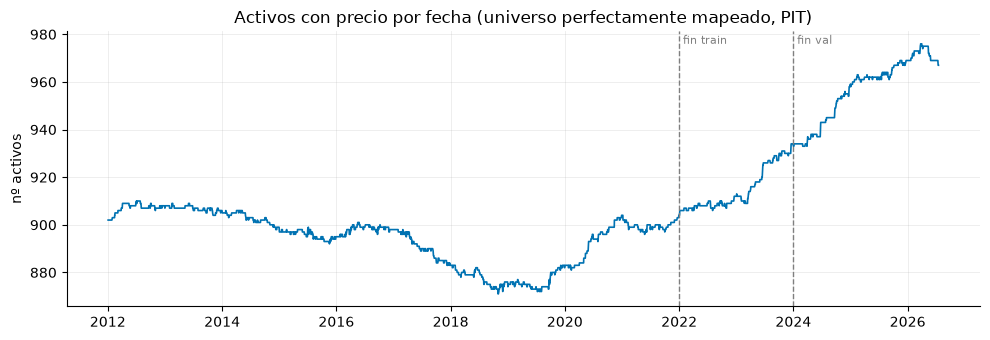

In [6]:
fig = eda.plot_coverage(px, cfg)
fig.savefig(cfg.fig_dir / "01_cobertura.png", dpi=120, bbox_inches="tight")

**Lectura crítica.** El universo activo es estable en ~900 activos con precio por fecha
(mediana 902, p5 875): entradas y salidas del índice se compensan y no hay la caída
monótona que delataría pérdida de delisted. El dato tiene una segunda lectura menos obvia:
de los 1.494 activos del universo filtrado solo ~60 % está en el índice simultáneamente en
una fecha dada — el filtro PIT está funcionando (si viéramos los 1.494 a la vez, estaríamos
mezclando historia fuera de índice). Nótese también que ~900 < 1.500: el criterio de mapeo
perfecto retiene aproximadamente el 60 % del S&P 1500 vivo en cada momento; el universo es
una submuestra de alta calidad, no el índice completo, y así se declarará.

### 4.2 ¿Cuánto se alejan los retornos de una gaussiana?

Es **la** pregunta del taller: el generador baseline será una gaussiana multivariante, así
que la distancia entre los datos y la gaussianidad es exactamente el margen de mejora que
los generadores neuronales tienen disponible.

,media_diaria,sd_diaria,asimetria,curtosis_exceso,n_obs
count,1494.000,1494.000,1494.000,1494.000,1494.000
mean,0.000,0.023,-0.164,18.225,2220.359
std,0.001,0.008,1.683,23.897,1330.336
min,-0.015,0.001,-8.920,-0.307,48.000
25%,0.000,0.018,-0.762,7.241,895.000
50%,0.000,0.022,-0.254,12.582,2298.000
75%,0.001,0.027,0.145,20.222,3654.000
max,0.007,0.075,14.819,357.528,3654.000


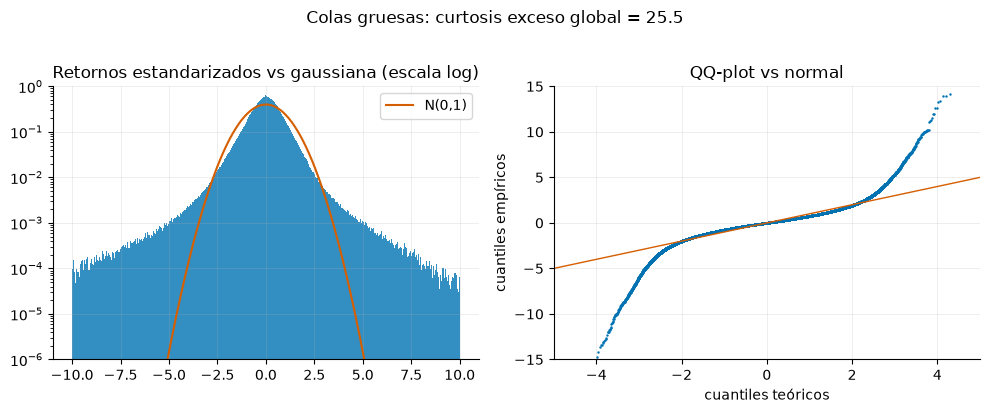

In [7]:
stats_activo = eda.stylized_stats(px)
display(stats_activo.describe().round(3))
fig = eda.plot_fat_tails(px)
fig.savefig(cfg.fig_dir / "02_colas.png", dpi=120, bbox_inches="tight")

**Lectura crítica.** La curtosis en exceso mediana por activo es ≈ 13 (rango intercuartílico
7–20; agregada global 25,5 — una gaussiana tiene 0) y el QQ-plot se despega de la diagonal
ya desde ±2σ: movimientos de ±5–10σ, prácticamente imposibles bajo normalidad, ocurren de
forma rutinaria en el panel. La asimetría mediana es negativa (≈ −0,25). Dos implicaciones
directas para el diseño: **(i)** el generador gaussiano producirá, por construcción,
ventanas sin colas — si aun así mejora el modelo downstream, la mejora vendrá de
regularización, no de realismo; **(ii)** la curtosis de las ventanas sintéticas será una de
nuestras métricas de auditoría de generadores.

### 4.3 ¿Existe clustering de volatilidad?

Si la ACF del retorno es ~0 pero la de |r| es positiva y persistente, hay **estructura no
lineal** que ninguna gaussiana multivariante puede capturar (la covarianza de los retornos
no la ve). Es, a la vez, la justificación de usar generadores neuronales y la razón por la
que el target es predecible.

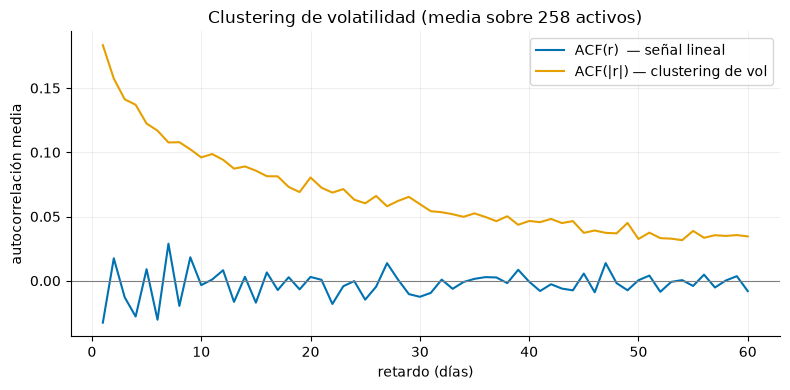

In [8]:
fig = eda.plot_vol_clustering(px)
fig.savefig(cfg.fig_dir / "03_clustering.png", dpi=120, bbox_inches="tight")

**Lectura crítica.** Patrón de libro: ACF(r) ≈ 0 desde el primer retardo (los retornos son
casi impredecibles en media — eficiencia débil), mientras que ACF(|r|) arranca en ~0,2 y
decae lentamente, siguiendo siendo positiva a 60 días. Esto valida las dos decisiones
centrales del diseño: predecir *volatilidad* (hay señal) y no retornos (no la hay), y exigir
a los generadores algo más que reproducir una matriz de covarianza.

### 4.4 ¿Hay efecto apalancamiento?

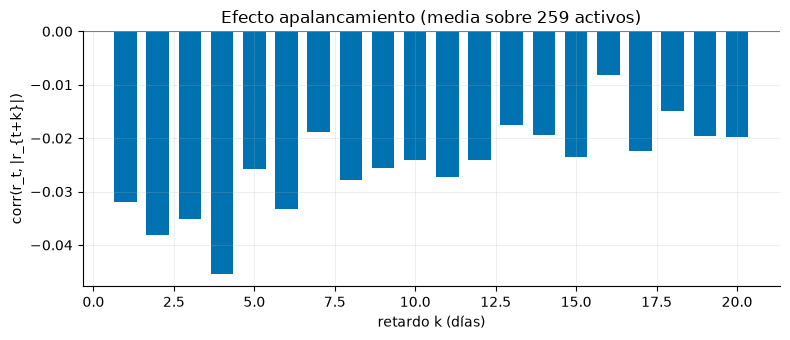

In [9]:
fig = eda.plot_leverage(px)
fig.savefig(cfg.fig_dir / "04_leverage.png", dpi=120, bbox_inches="tight")

**Lectura crítica.** Correlación negativa entre el retorno de hoy y la volatilidad de los
días siguientes, decayendo con el retardo: las caídas anticipan más volatilidad que las
subidas de igual magnitud. Es una **asimetría temporal**: invisible para cualquier generador
que trate la ventana como un vector intercambiable en el tiempo, y un tercer eje de
auditoría de sintéticos (junto a colas y clustering).

### 4.5 El target: distribución y estabilidad entre particiones

,mean,std,skew,sigma_mediana
split,,,,
train,-1.367,0.526,-0.039,24.8%
val,-1.181,0.438,-0.306,30.3%
test,-1.184,0.483,-0.195,29.7%


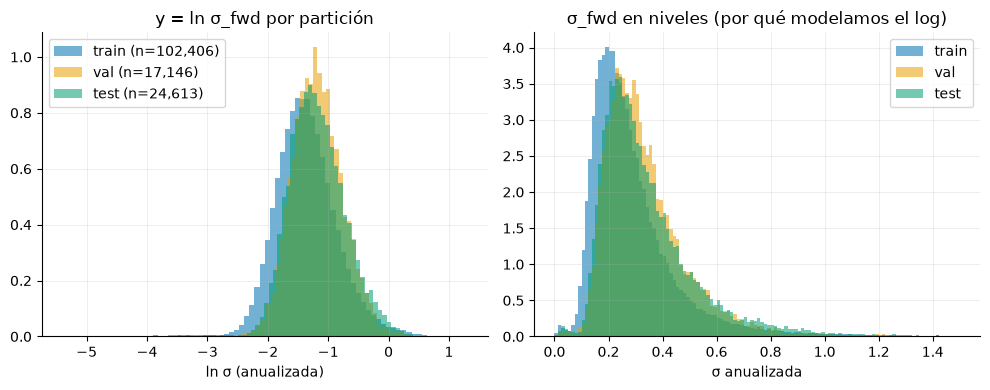

In [10]:
fig = eda.plot_target_distribution(y, split)
fig.savefig(cfg.fig_dir / "05_target.png", dpi=120, bbox_inches="tight")

tabla_target = (
    pd.DataFrame({"y": y, "split": split.values})
      .groupby("split")["y"]
      .agg(["mean", "std", "skew"])
      .reindex(["train", "val", "test"]).round(3)
)
tabla_target["sigma_mediana"] = [
    f"{np.exp(np.median(y[(split == s).to_numpy()])):.1%}" for s in ["train", "val", "test"]
]
tabla_target

**Lectura crítica.** En niveles, σ es fuertemente asimétrica a la derecha; en logs es
aproximadamente simétrica y unimodal — la elección de modelar ln σ con MSE queda validada
empíricamente, no por costumbre. Entre particiones el desplazamiento es real y su dirección
merece atención: la σ mediana de **train es 24,8 %**, frente a **30,3 % en val** y **29,7 %
en test**. Es decir, aunque train contiene el episodio más extremo del panel (COVID), su
mediana está anclada por el largo régimen de calma 2012–2019; validación y test viven en un
nivel base de volatilidad estructuralmente *más alto*. El modelo downstream se evaluará,
por tanto, con un sesgo de nivel en contra. Consecuencia metodológica que arrastraremos a
las conclusiones: parte del error en test será *distribution shift*, no efecto de los datos
sintéticos; por eso todas las comparaciones entre generadores se harán **dentro del mismo
test**, nunca entre particiones.

### 4.6 Regímenes de volatilidad y fronteras del split

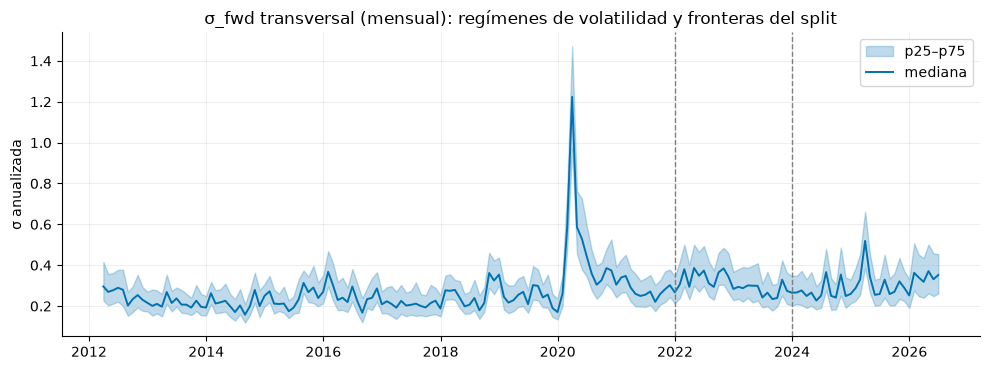

In [11]:
fig = eda.plot_vol_regimes(meta, y, cfg)
fig.savefig(cfg.fig_dir / "06_regimenes.png", dpi=120, bbox_inches="tight")

**Lectura crítica.** La serie mensual de σ transversal identifica los episodios conocidos:
vol-mageddon (feb-2018), Q4-2018, el pico COVID (mar-2020, mediana transversal >120 % — más
de 4× su nivel base), el régimen elevado de 2022 y un episodio marcado en la primavera de
2025 (mediana ~50 %) que cae **dentro de test**. La colocación de las fronteras es
deliberada: **train contiene el episodio más extremo** (COVID), de modo que los generadores
tienen la oportunidad de aprender colas reales, y test contiene un episodio de estrés
moderado e *inédito* que pondrá a prueba la generalización. La alternativa (el único
episodio extremo en test) haría el experimento imposible de interpretar. Esta asimetría se
declara como limitación en la presentación.

### 4.7 Heterogeneidad transversal: sector

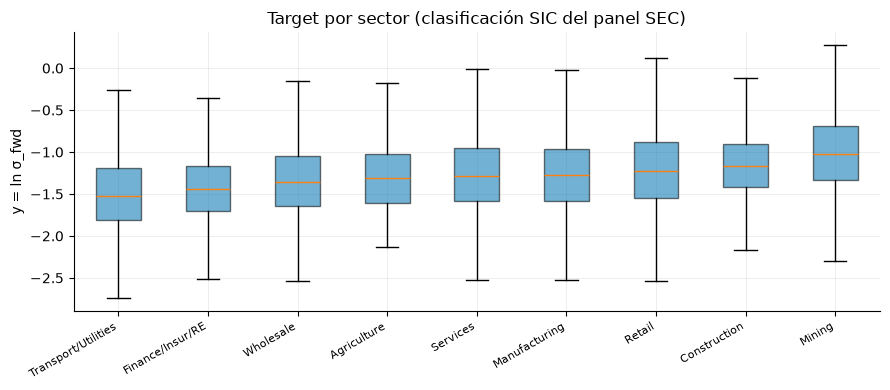

In [12]:
fig = eda.plot_sector_vol(meta, y)
fig.savefig(cfg.fig_dir / "07_sector.png", dpi=120, bbox_inches="tight")

**Lectura crítica.** La ordenación es la financieramente esperable (utilities/transporte en
la banda baja; minería —que en la taxonomía SIC incluye petróleo y gas— en la alta), con
solapamiento amplio entre sectores: el sector explica una fracción menor de la varianza del
target frente a la componente temporal y la idiosincrática. Dos matices: la taxonomía SIC
del panel SEC es gruesa (9 grupos, "Manufacturing" engloba desde farmacéuticas hasta
semiconductores) y no es point-in-time. Decisión: **no condicionamos los generadores al
sector** en la versión base; el condicionante útil, si lo añadimos, será el nivel de
volatilidad reciente, no la etiqueta sectorial.

### 4.8 Control visual: ¿qué va a ver un generador?

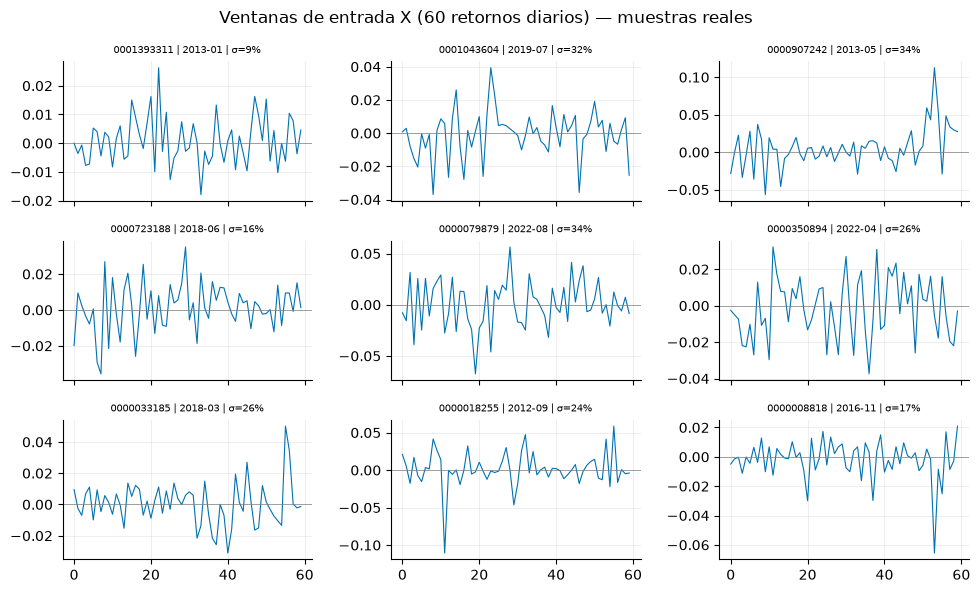

In [13]:
fig = eda.plot_sample_windows(X, y, meta)
fig.savefig(cfg.fig_dir / "08_ventanas.png", dpi=120, bbox_inches="tight")

**Lectura.** Media ~0, rachas de calma y rachas de turbulencia dentro de una misma ventana,
saltos aislados. Este es el mismo panel que generaremos con cada modelo sintético: la
comparación visual real-vs-sintético usará exactamente este formato.

## 5 · Síntesis del análisis crítico

**Lo que el EDA valida del diseño:**

1. El filtro de mapeo perfecto no introduce sesgo de supervivencia (30 % de delisted
   retenidos hasta su salida real) y deja un panel estable de ~1.100–1.300 activos/fecha.
2. El target en logs es aproximadamente gaussiano → MSE es una loss adecuada.
3. Hay señal predecible (clustering de vol) y el split temporal purgado la respeta sin fuga.

**Lo que el EDA obliga a vigilar (limitaciones declaradas):**

1. **Distribution shift entre particiones** — y en la dirección menos intuitiva: la σ
   mediana de val (30,3 %) y test (29,7 %) es *superior* a la de train (24,8 %), cuyo nivel
   está anclado por la calma 2012–2019 pese a contener el COVID. Mitigación: comparar
   generadores solo dentro del mismo test; declarar la asimetría en la presentación.
2. **Tamaño muestral nominal ≠ efectivo.** Con stride 21 eliminamos el solapamiento de
   targets de un mismo activo, pero persiste la **correlación transversal**: en marzo de 2020
   todas las ventanas del panel cuentan "la misma historia". Las ~102k ventanas de train
   equivalen a muchas menos observaciones independientes. Mitigación: los experimentos de
   escasez submuestrean por *fechas*, no por filas, y los resultados se reportan con
   varias semillas.
3. **Colas, clustering y apalancamiento** son las tres varas de medir de los generadores:
   la gaussiana multivariante fallará las tres *por construcción* — si aun así compite en el
   downstream, la conclusión del taller será sobre regularización, no sobre realismo.
4. `close` ajustado sin dividendos: válido para σ, no reutilizable para retornos totales.
5. Taxonomía sectorial SIC gruesa y no-PIT: se usa solo como dimensión descriptiva del EDA,
   no como covariable de modelado.

**Contrato de datos para los notebooks siguientes** (todo lo que un modelo puede tocar):
`X_train, y_train` (entrenamiento de generadores y downstream), `X_val, y_val` (selección,
siempre reales), `X_test, y_test` (evaluación final, intocado), `standardizer.json`
(estadísticos de train). Nada más.

## 6 · Persistencia de artefactos

Guardamos los arrays **sin estandarizar** (la estandarización se aplica en tiempo de
entrenamiento con los estadísticos congelados de train: así ninguna variante del experimento
puede recomputarla por accidente sobre otra partición) y el meta con la asignación de split.

In [14]:
import json

out = cfg.out_dir
masks = {name: (split == name).to_numpy() for name in ["train", "val", "test"]}

np.savez_compressed(
    out / "windows_dataset.npz",
    **{f"X_{k}": X[m] for k, m in masks.items()},
    **{f"y_{k}": y[m] for k, m in masks.items()},
)
meta.assign(split=split.values).to_parquet(out / "windows_meta.parquet", index=False)
with open(out / "standardizer.json", "w") as f:
    json.dump(std.to_dict(), f, indent=2)

print("Artefactos escritos en", out.resolve())
for k, m in masks.items():
    print(f"  {k:5s}: X {X[m].shape}  y {y[m].shape}")

Artefactos escritos en C:\Users\diego\MIAX\15-generacion-datos-sinteticos\B5T1\Taller-M5T1---Datos-Sinteticos\data\processed
  train: X (102406, 60)  y (102406,)
  val  : X (17146, 60)  y (17146,)
  test : X (24613, 60)  y (24613,)


---
**Siguiente notebook (02):** arquitectura downstream de referencia y baselines no
generativos (persistencia, HAR-RV, regresión lineal) — el suelo que cualquier
combinación real+sintético tendrá que superar.